In [103]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax
from functools import partial

from probjax.core.stochastic_inverses.inverse_factorys import inverse_matrix_vector_multiplication
from probjax.distributions import Normal

from sbi.analysis import pairplot

from probjax.core.random_variable import rv 
from probjax.core.transformations import joint_sample

import matplotlib.pyplot as plt

In [110]:
x_dim = 1
theta_dim = 1

prior = Normal(jnp.zeros(theta_dim), jnp.ones(theta_dim))
noise = rv(Normal(0.,1.), "noise")


def sim(key, theta):
    z = theta**2
    x = z + noise(key)
    return x

simulator = jax.vmap(sim)
joint_simulator = joint_sample(simulator)


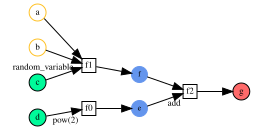

In [112]:
from probjax.core.graph import JaxprGraph, propagate, inverse_cost_fn
import networkx as nx
jaxpr = jax.make_jaxpr(sim)(jrandom.PRNGKey(0), jnp.ones(theta_dim))
g = JaxprGraph(jaxpr.jaxpr.invars, jaxpr.jaxpr.constvars, jaxpr.jaxpr.outvars, jaxpr.jaxpr.eqns)
g

In [119]:
import haiku as hk
import distrax

@hk.without_apply_rng
@hk.transform
def model(x):
    mlp = hk.Sequential([
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(31),
        hk.Reshape(tuple((1,)) + (31,), preserve_dims=-1),
    ])
    out = mlp(x)
    t = distrax.RationalQuadraticSpline(out, range_min=-5., range_max=5)
    #transforms = distrax.Chain([distrax.ScalarAffine(x + 0.1, -1.),distrax.Lambda(lambda x: jnp.exp(x)),t])
    transforms = distrax.Chain([t])
    #return distrax.Transformed(distrax.Normal(0, 1.), transforms)
    return distrax.Transformed(distrax.Uniform(-5., 5.), transforms)

params = model.init(jax.random.PRNGKey(42), jnp.ones((1,)))
params = jax.tree_map(lambda x: x * 0.1, params)
f = model.apply

In [120]:
thetas = prior.sample(jrandom.PRNGKey(0), (10000,))
xs, latent= joint_simulator(jrandom.split(jrandom.PRNGKey(0), 10000), thetas)
latent = latent["noise"]

In [126]:
# Train based on the latents collected from forward model

def conditional(key, x, params):
    q = f(params, x)
    noise = q.sample(sample_shape=(10000,), seed=key)
    z = x - noise
    return z, noise

@partial(jax.vmap, in_axes=(None, 0,0))
def loss_fn(params, x, latents):
    q = f(params, x)
    log_prob = q.log_prob(latents)# + Normal(0., 1.).log_prob(q.sample(seed=jrandom.PRNGKey(0)))
    return -jnp.mean(log_prob)

@jax.jit 
@jax.grad
def loss_grad(params):
    return loss_fn(params, xs, latent).mean()

In [127]:
import optax 

opt = optax.adam(0.001)
opt_state = opt.init(params)

for i in range(500):
    gradient = loss_grad(params)
    updates, opt_state = opt.update(gradient,opt_state)
    params = optax.apply_updates(params, updates)

In [129]:
def inverse_simulator(key, x):
    key1, key2 = jrandom.split(key)
    noise = f(params, x).sample(seed=key1)
    z = x-noise
    z_sqrt = jrandom.choice(key2, jnp.asarray([-1.,1.])) * jnp.sqrt(jnp.abs(z))
    return z_sqrt

In [130]:
def log_potential(theta,x):
    z = theta**2
    return Normal(z,1.).log_prob(x) + Normal(0.,1.).log_prob(theta)

In [131]:
inverse_simulator(jrandom.PRNGKey(0), jnp.array([10.]))

Array([-3.0766983], dtype=float32)

In [132]:
x = jnp.linspace(-10,10,1000)
unnormalized_posterior =jnp.exp(jax.vmap(log_potential)(x, jnp.ones(1000)*4.))
posterior = unnormalized_posterior / jnp.trapz(unnormalized_posterior, x)


In [133]:
thetas_post = jax.vmap(inverse_simulator, in_axes=(0, None))(jrandom.split(jrandom.PRNGKey(0), 10000), jnp.ones(1)*4.)

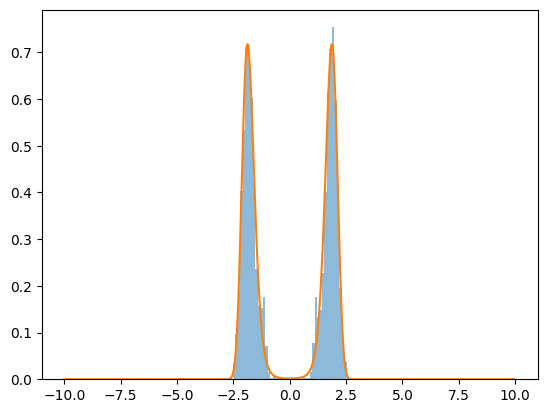

In [134]:
_ = plt.hist(jnp.squeeze(thetas_post), bins=50, density=True, alpha=0.5)
plt.plot(x, posterior)

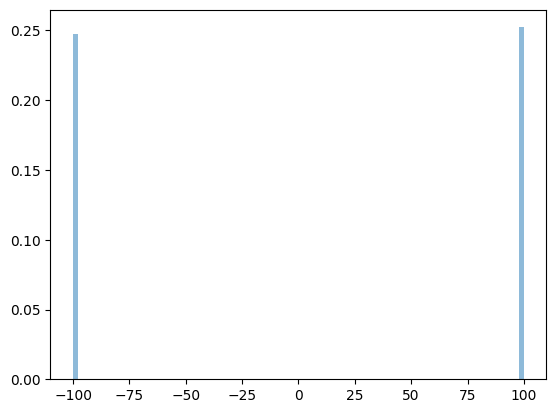

In [135]:
thetas_post = jax.vmap(inverse_simulator, in_axes=(0, None))(jrandom.split(jrandom.PRNGKey(0), 10000), jnp.ones(1)*10000.)
_ = plt.hist(jnp.squeeze(thetas_post), bins=100, density=True, alpha=0.5)